In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv("modified_data-selected-columns.csv")

In [34]:
df


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,yr_built,city,price_per_sqft
0,2014-05-02,313000.00,3.0,1.50,1340,7912,1.5,3,1955,Shoreline,233.58
1,2014-05-02,2384000.00,5.0,2.50,3650,9050,2.0,5,1921,Seattle,653.15
2,2014-05-02,342000.00,3.0,2.00,1930,11947,1.0,4,1966,Kent,177.20
3,2014-05-02,420000.00,3.0,2.25,2000,8030,1.0,4,1963,Bellevue,210.00
4,2014-05-02,550000.00,4.0,2.50,1940,10500,1.0,4,1976,Redmond,283.51
...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09,308166.67,3.0,1.75,1510,6360,1.0,4,1954,Seattle,204.08
4596,2014-07-09,534333.33,3.0,2.50,1460,7573,2.0,3,1983,Bellevue,365.98
4597,2014-07-09,416904.17,3.0,2.50,3010,7014,2.0,3,2009,Renton,138.51
4598,2014-07-10,203400.00,4.0,2.00,2090,6630,1.0,3,1974,Seattle,97.32


In [14]:
df.isna().sum()

date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
condition         0
yr_built          0
city              0
price_per_sqft    0
dtype: int64

In [41]:
df.dtypes

date              datetime64[ns]
price                    float64
bedrooms                   int64
bathrooms                  int64
sqft_living                int64
sqft_lot                   int64
floors                     int64
condition                  int64
yr_built                   int64
city                      object
price_per_sqft           float64
dtype: object

In [9]:
df.city.unique()

array(['Shoreline', 'Seattle', 'Kent', 'Bellevue', 'Redmond',
       'Maple Valley', 'North Bend', 'Lake Forest Park', 'Sammamish',
       'Auburn', 'Des Moines', 'Bothell', 'Federal Way', 'Kirkland',
       'Issaquah', 'Woodinville', 'Normandy Park', 'Fall City', 'Renton',
       'Carnation', 'Snoqualmie', 'Duvall', 'Burien', 'Covington',
       'Inglewood-Finn Hill', 'Kenmore', 'Newcastle', 'Mercer Island',
       'Black Diamond', 'Ravensdale', 'Clyde Hill', 'Algona', 'Skykomish',
       'Tukwila', 'Vashon', 'Yarrow Point', 'SeaTac', 'Medina',
       'Enumclaw', 'Snoqualmie Pass', 'Pacific', 'Beaux Arts Village',
       'Preston', 'Milton'], dtype=object)

In [36]:
df.duplicated().sum()

0

In [37]:
df.date=pd.to_datetime(df.date,errors = 'coerce')

In [38]:
df.bedrooms = df.bedrooms.astype('int64')

In [39]:
df.bathrooms = df.bathrooms.astype('int64')

In [40]:
df.floors = df.floors.astype('int64')

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

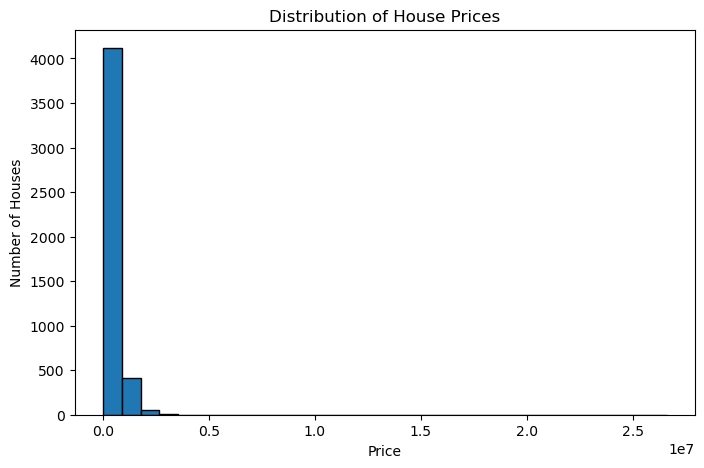

In [42]:
plt.figure(figsize=(8, 5))

plt.hist(df["price"], bins=30, edgecolor="black")

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

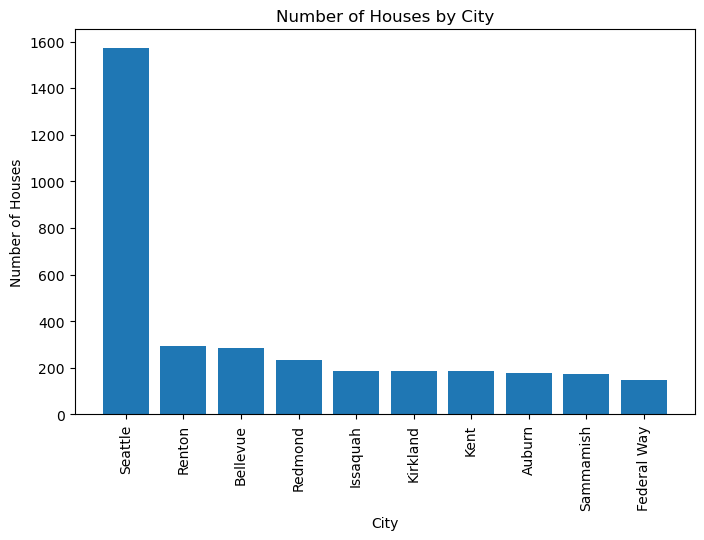

In [61]:
city_counts = df["city"].value_counts().head(10)


plt.figure(figsize=(8, 5))

plt.bar(city_counts.index, city_counts.values)

plt.title("Number of Houses by City")
plt.xlabel("City")
plt.ylabel("Number of Houses")

plt.xticks(rotation=90)
plt.show()

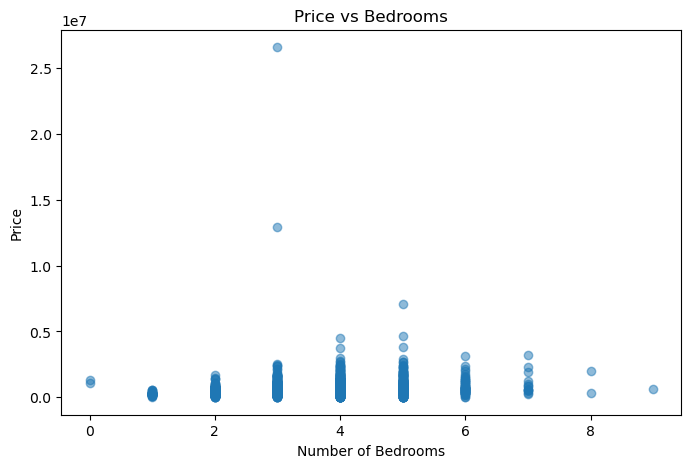

In [45]:
plt.figure(figsize=(8, 5))

plt.scatter(df["bedrooms"], df["price"], alpha=0.5)

plt.title("Price vs Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")

plt.show()

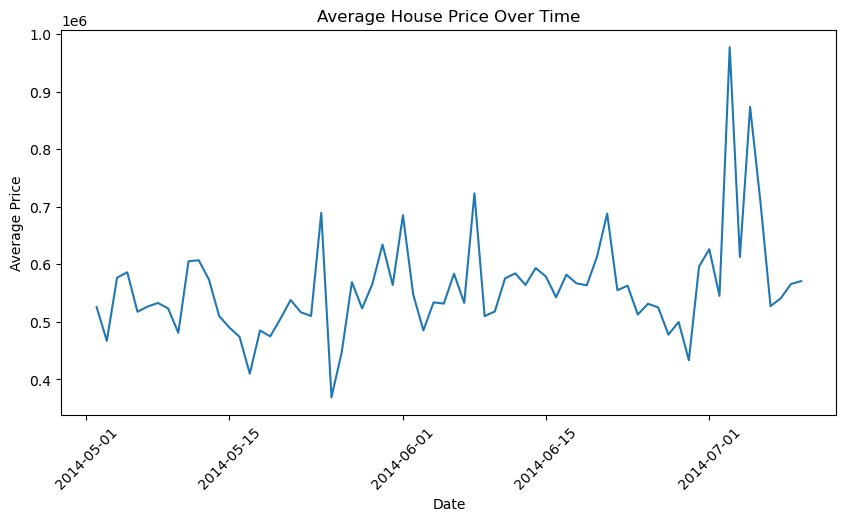

In [46]:
daily_price = df.groupby("date")["price"].mean()

plt.figure(figsize=(10, 5))

plt.plot(daily_price.index, daily_price.values)

plt.title("Average House Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price")

plt.xticks(rotation=45)
plt.show()

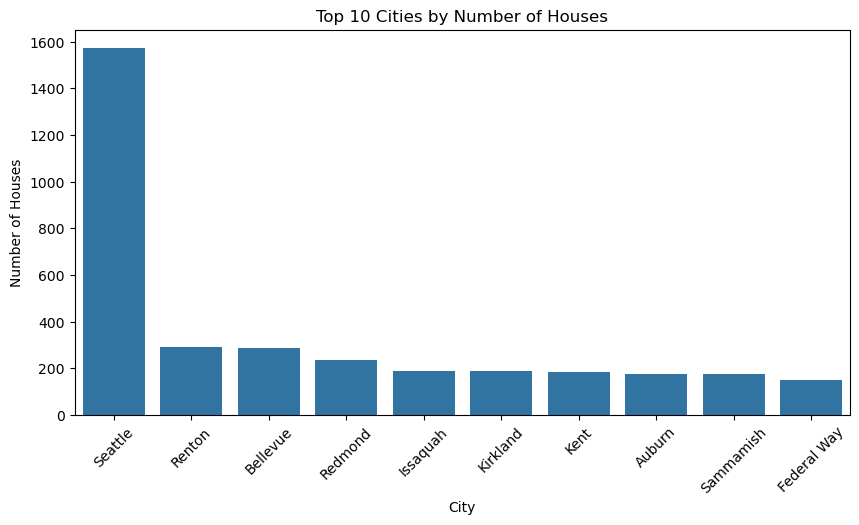

In [51]:
plt.figure(figsize=(10, 5))

top_10_cities = df["city"].value_counts().head(10)

sns.barplot(x=top_10_cities.index,y=top_10_cities.values)

plt.title("Top 10 Cities by Number of Houses")
plt.xlabel("City")
plt.ylabel("Number of Houses")

plt.xticks(rotation=45)
plt.show()

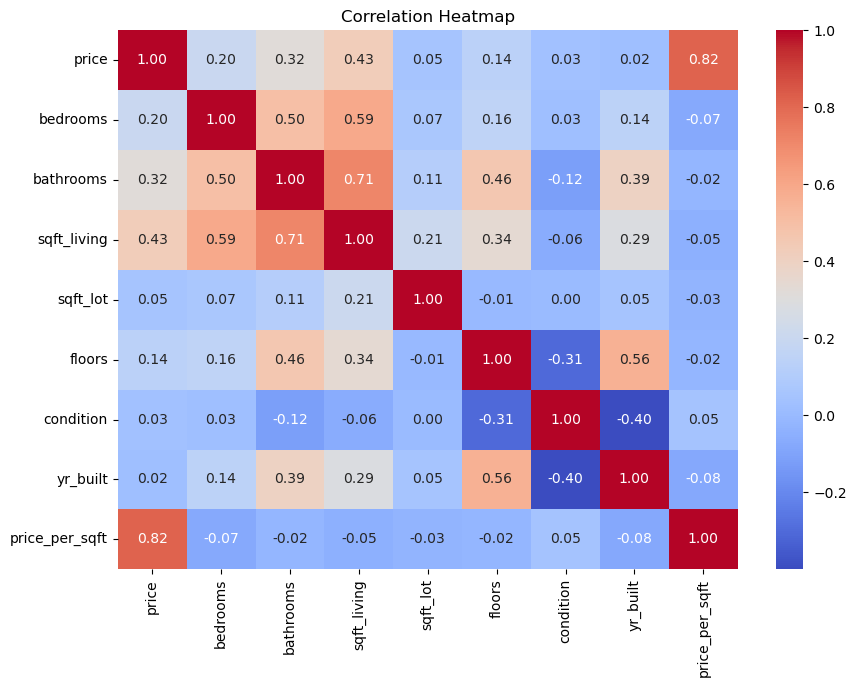

In [55]:
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

sns.heatmap(correlation,annot=True,cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

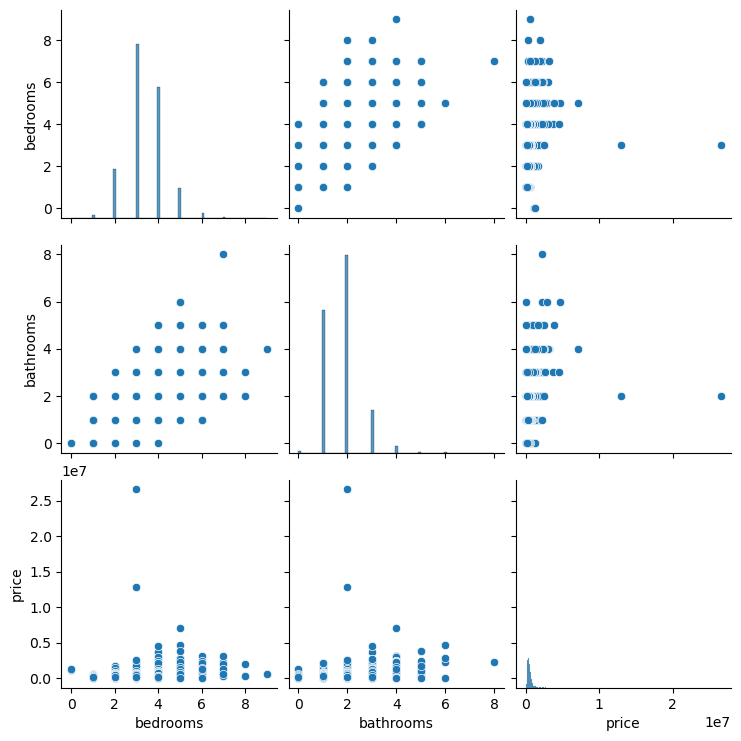

In [65]:
sns.pairplot(df, vars = ['bedrooms','bathrooms','price'])

plt.show()